In [1]:
import numpy as np
import json
import csv
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import matplotlib.font_manager as font_manager
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Plot embedding before rotation (Fig. 1, left panel)

In [2]:
mp_ca = pd.read_csv('./data/mp_embedding_pseudo_before_rotation.csv', dtype = str)

In [3]:
colmap = {'FDP': 'yellow', 'Bündnis 90/Die Grünen': 'green', 'AfD': 'blue', 'DIE LINKE': 'deeppink',
'CDU': 'black', 'CSU': 'black', 'SPD': 'red', 'SSW': 'grey', 'CDU/CSU': 'black'}

party_list = list(mp_ca.party)

for idx, element in enumerate(party_list):
    party_list[idx] = colmap[element]

In [4]:
user_embedding = './data/embedding_pseudo_before_rotation.csv'

user_basic = pd.read_csv(user_embedding, dtype = str)
user_basic = user_basic.set_index('user')

user_basic = user_basic[['0', '2']]

In [5]:
def plot_ca(user_df, MP_df, party_list, follower_color, follower_alpha, hist_alpha, density=True):
    
    FOLLOWER_COLOR = follower_color
    FOLLOWER_ALPHA = follower_alpha
    STORY_COLOR_MEAN = "red"    
    
    #title = outlet + ': Outlet sharing distribution'
    
    x = list(user_df['0'])
    y = list(user_df['2'])
    x = [float(s) for s in x if s!='not_embedded']
    y = [float(s) for s in y if s!='not_embedded']
    mean_x = sum(x)/len(x)
    mean_y = sum(y)/len(y)    
    MP_df['0'] = MP_df['0'].astype(float)
    MP_df['2'] = MP_df['2'].astype(float)
    x_mp = list(MP_df['0'])
    y_mp = list(MP_df['2'])
    
    fig = plt.figure(figsize=(10,10))
    
    gs = fig.add_gridspec(2, 2,  width_ratios=(7, 1), height_ratios=(1, 7),
                          left=0.1, right=0.9, bottom=0.1, top=0.9,
                          wspace=0.005, hspace=0.005)
    
    ## define axes
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)    
    
    if density == True:
        plot = sns.kdeplot(x=x, y=y, levels=20, color="darkseagreen", 
                    fill = False,alpha = 1, zorder = 2, ax=ax)
        
        sharer_patch = Line2D([0], [0], color=follower_color, 
                       markerfacecolor=follower_color)
        
    else:
        plot = ax.scatter(x=x, y=y, c=FOLLOWER_COLOR, 
                    alpha = .1, zorder = 2, marker = 'x')
    #smean = ax.scatter(mean_x, mean_y, c = 'red', marker = 'x', s = 150, zorder = 3)
    #colorlist = list(pol_df['color'])

    MP_df.plot(kind='scatter', x = '0', y = '2', c = party_list, zorder = 3, marker = 'o', ax=ax, 
               alpha = .5, edgecolors='black', s=25)    
    
#     ax.set_title(outlet + ': Outlet sharing distribution')
    
    ## title and axis labels

    
    ax.set_xlabel('Left-right', fontsize = 17)
    ax.set_ylabel('Elite-/EU-skeptical/Protectionist', fontsize = 17)
    ax.set_ylim(-2.5,2)
    ax.set_xlim(-1,4)     
    
    ## define and draw histograms
    binwidth = 0.05
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth
    bins = np.arange(-lim, lim + binwidth, binwidth)    
    ax_histx.hist(x, bins=bins, density=False,color=FOLLOWER_COLOR,alpha=hist_alpha)
    ax_histy.hist(y, bins=bins, orientation='horizontal',color=FOLLOWER_COLOR,alpha=hist_alpha)                
    
    ## some details
    ax_histx.axis('off')
    ax_histy.axis('off')
    ax.grid(alpha=.3)
    ax.tick_params(direction='in',which='both',width=1,top=True,right=True)
    ax.tick_params(direction='in',which='major',width=1,length=10)
    ax.tick_params(direction='in',which='minor',width=1,length=5)    
    
    ## add a custom legend element for the party positions
    patch = Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor='w', markeredgecolor='black', markersize=6)
    
    ## define legend
    if density == True:
        legend = ax.legend([sharer_patch, patch],
                           ('User distribution', 'MPs'),
                           loc=(0.03, 0.05),
                           fontsize = 17
                          )
    else:
        legend = ax.legend([plot, patch],
                           ('users', 'MPs'),
                           loc=(0.03, 0.05),
                           fontsize = 17
                          )        
    
    # make sure all legend markers have the same size
    for marker_idx in range(2):
        legend.legend_handles[marker_idx]._sizes = [50]
    #plt.savefig('basic_CA.pdf', dpi = 300)
    plt.show()
    plt.close()
    
    return None    

In [ ]:
plot_ca(user_basic, mp_ca, party_list, 'darkseagreen', .4, .8, density=True)

# Plot embedding and average party positions after rotation (Fig. 1, right panel)

Load MP positions (this will just produce the MP scatter plot)

In [12]:
party_positions = pd.read_csv('./data/party_pos_FINAL.csv')

In [13]:
user_embedding = './data/embedding_pseudo.csv'

user_emb_df = pd.read_csv(user_embedding, dtype = str)
user_emb_df = user_emb_df.set_index('user')

In [47]:
def plot_embedding_final(user_df, party_positions, follower_color, follower_alpha, hist_alpha, density=True):
    
    FOLLOWER_COLOR = follower_color
    FOLLOWER_ALPHA = follower_alpha
    STORY_COLOR_MEAN = "red"    
    
    #title = outlet + ': Outlet sharing distribution'
    
    x = list(user_df['0'])
    y = list(user_df['2'])
    x = [float(s) for s in x if s!='not_embedded']
    y = [float(s) for s in y if s!='not_embedded']
    mean_x = sum(x)/len(x)
    mean_y = sum(y)/len(y)    
    party_positions['0'] = party_positions['0'].astype(float)
    party_positions['2'] = party_positions['2'].astype(float)
    x_mp = list(party_positions['0'])
    y_mp = list(party_positions['2'])
    
    fig = plt.figure(figsize=(10,10))
    
    gs = fig.add_gridspec(2, 2,  width_ratios=(7, 1), height_ratios=(1, 7),
                          left=0.1, right=0.9, bottom=0.1, top=0.9,
                          wspace=0.005, hspace=0.005)
    
    ## define axes
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)    
    
    if density == True:
        plot = sns.kdeplot(x=x, y=y, levels=20, color="darkseagreen", 
                    fill = False,alpha = 1, zorder = 2, ax=ax)
        
        sharer_patch = Line2D([0], [0], color=follower_color, 
                       markerfacecolor=follower_color)
        
    else:
        plot = ax.scatter(x=x, y=y, c=FOLLOWER_COLOR, 
                    alpha = .1, zorder = 2, marker = 'x')
    #smean = ax.scatter(mean_x, mean_y, c = 'red', marker = 'x', s = 150, zorder = 3)
    #colorlist = list(pol_df['color'])
    color_list = list(party_positions['color'])
    party_positions.plot(kind='scatter', x = '0', y = '2', c = color_list, zorder = 3, marker = 'o', ax=ax, 
               alpha = .5, edgecolors='black', s=60)    
    
#     ax.set_title(outlet + ': Outlet sharing distribution')
    
    ## title and axis labels

    
    ax.set_xlabel('Left-right', fontsize = 17)
    ax.set_ylabel('Elite-/EU-skeptical/Protectionist', fontsize = 17)
    ax.set_ylim(-2,4)
    ax.set_xlim(-3,3)     
    
    ## define and draw histograms
    binwidth = 0.05
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth
    bins = np.arange(-lim, lim + binwidth, binwidth)    
    ax_histx.hist(x, bins=bins, density=False,color=FOLLOWER_COLOR,alpha=hist_alpha)
    ax_histy.hist(y, bins=bins, orientation='horizontal',color=FOLLOWER_COLOR,alpha=hist_alpha)                
    
    ## some details
    ax_histx.axis('off')
    ax_histy.axis('off')
    ax.grid(alpha=.3)
    ax.tick_params(direction='in',which='both',width=1,top=True,right=True)
    ax.tick_params(direction='in',which='major',width=1,length=10)
    ax.tick_params(direction='in',which='minor',width=1,length=5)    
    
    ## add a custom legend element for the party positions
    patch = Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor='w', markeredgecolor='black', markersize=6)
    
    ## define legend
    if density == True:
        legend = ax.legend([sharer_patch, patch],
                           ('User distribution', 'Parties'),
                           loc=(0.03, 0.05),
                           fontsize = 17
                          )
    else:
        legend = ax.legend([plot, patch],
                           ('users', 'Parties'),
                           loc=(0.03, 0.05),
                           fontsize = 17
                          )        
    
    # make sure all legend markers have the same size
    for marker_idx in range(2):
        legend.legend_handles[marker_idx]._sizes = [50]
    #plt.savefig('basic_embedding.pdf', dpi = 300)
    plt.show()
    plt.close()
    
    return None    

/var/folders/_p/7vwplj9155x7q1tghmrxfnlr0000gp/T/ipykernel_12758/3628936163.py:93: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  legend.legendHandles[marker_idx]._sizes = [50]


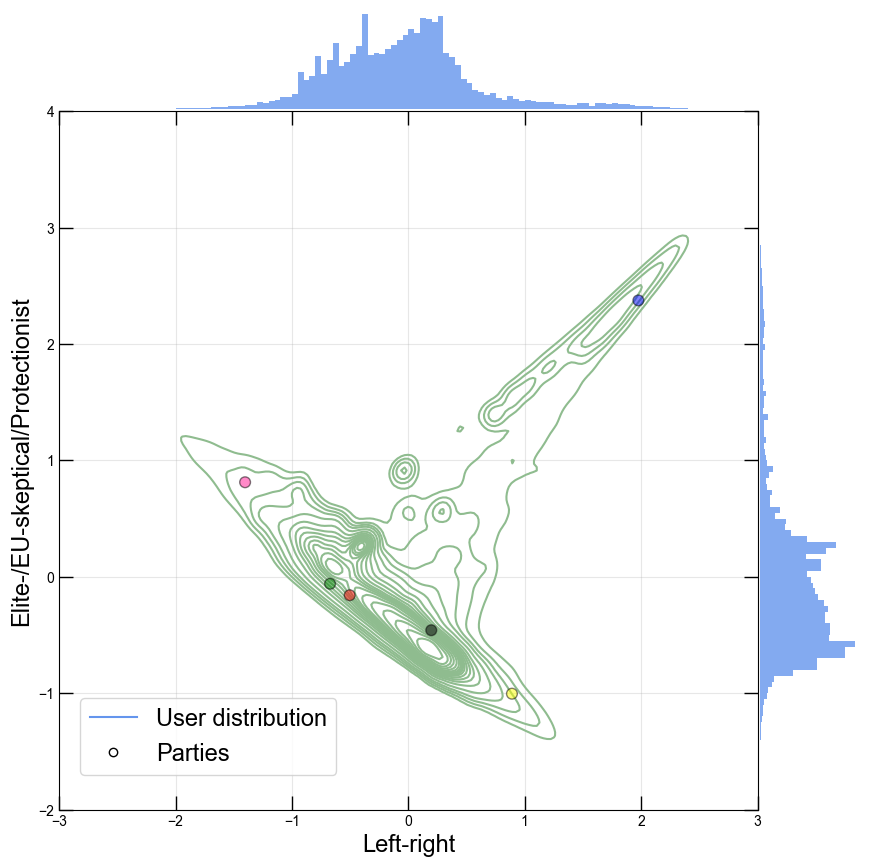

In [48]:
plot_embedding_final(user_emb_df, party_positions, follower_color='#6495ED', follower_alpha=.4, hist_alpha=.8)